<a href="https://colab.research.google.com/github/reddoma742/DTQEM-v12.2-Time-Sovereignty-Model-of-Quantum-Entanglement/blob/main/DTQEM%20v12.2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DTQEM v12.2 – Gold Release (fully corrected)
DOI: 10.5281/zenodo.20039345

=== BENCHMARKS (DTQEM v12.2) ===
✓ dephasing_error: 8.33e-16
✓ relaxation_error: 7.77e-16
✓ entropy_increase: True


Inverse γφ₀: target V=0.5000 → γφ₀ = 50000.00 (err=1.91e-01)
Inverse T: target V=0.5000 → T = 300.00 K (err=1.45e-01)
Inverse θ: target V=0.5000 → θ = 33.99° (err=4.58e-18)

=== BENCHMARKS (DTQEM v12.2) ===
✓ dephasing_error: 3.81e-17
✓ relaxation_error: 1.67e-15
✓ entropy_increase: True
✅ Validation report saved to dtqem_outputs_v12_2/validation_report.json


/tmp/ipykernel_1433/878455423.py:46: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  rho_A[i,k] = np.sum(rho[i,j,k,j] for j in range(2))


Inverse γφ₀: target V=0.1000 → γφ₀ = 50000.00 (err=1.60e-01)
Inverse θ: target V=0.1000 → θ = 6.42° (err=5.12e-18)
Inverse T: target V=0.1000 → T = 300.00 K (err=5.12e-18)


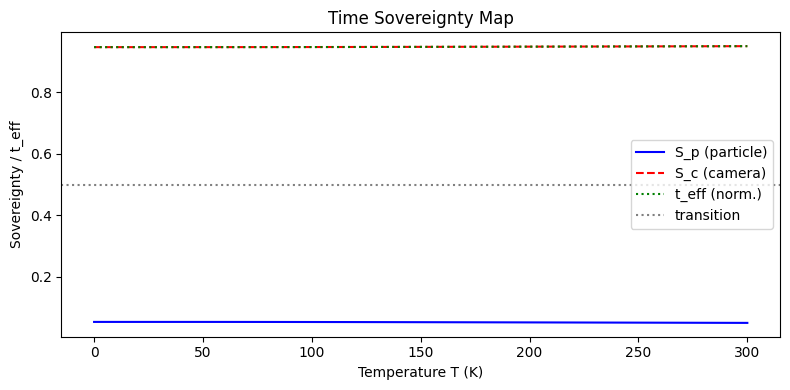

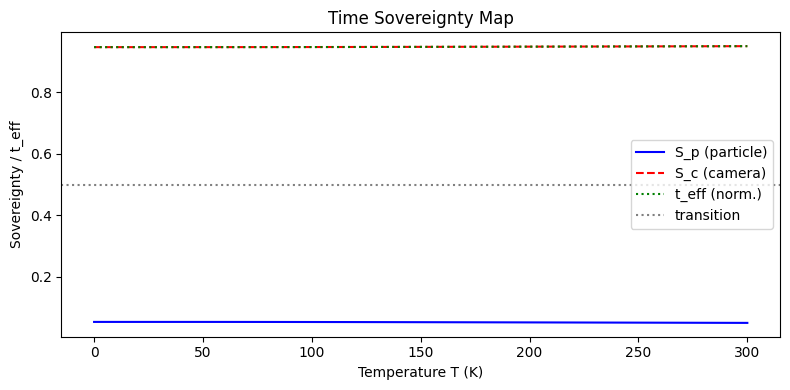


=== BENCHMARKS (DTQEM v12.2) ===
✓ dephasing_error: 3.81e-17
✓ relaxation_error: 1.67e-15
✓ entropy_increase: True
✅ Validation report saved to dtqem_outputs_v12_2/validation_report.json


/tmp/ipykernel_1433/878455423.py:46: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  rho_A[i,k] = np.sum(rho[i,j,k,j] for j in range(2))


Inverse γφ₀: target V=0.1000 → γφ₀ = 50000.00 (err=5.12e-18)
Inverse θ: target V=0.1000 → θ = 6.42° (err=5.12e-18)
Inverse T: target V=0.1000 → T = 300.00 K (err=5.12e-18)
Inverse γφ₀: target V=0.1000 → γφ₀ = 50000.00 (err=5.12e-18)


In [1]:

# -*- coding: utf-8 -*-
"""
DTQEM v12.2 – Final Gold Release (fully corrected)
Author: Redouane Berramdane
DOI: 10.5281/zenodo.20039345
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from scipy.special import sinc
from scipy.linalg import expm, sqrtm
from scipy.optimize import minimize_scalar, minimize
import ipywidgets as widgets
from IPython.display import display, clear_output
import csv, json, os

# ======================================================================
# Constants and core physics (identical to v12.1)
# ======================================================================
class Constants:
    hbar = 1.0545718e-34; k_B = 1.380649e-23; eV = 1.60217662e-19; mu_B = 9.2740100783e-24

I2 = np.eye(2, dtype=complex)
SX = np.array([[0,1],[1,0]], dtype=complex)
SY = np.array([[0,-1j],[1j,0]], dtype=complex)
SZ = np.array([[1,0],[0,-1]], dtype=complex)
SP = np.array([[0,1],[0,0]], dtype=complex)
SM = np.array([[0,0],[1,0]], dtype=complex)
def kron(a,b): return np.kron(a,b)

class QuantumState:
    @staticmethod
    def entangled_state(theta_deg):
        theta = np.radians(theta_deg); c = np.cos(theta/2); s = np.sin(theta/2)
        return np.array([c,0,0,s], dtype=complex)
    @staticmethod
    def bell_phi_plus(): return np.array([1,0,0,1], dtype=complex)/np.sqrt(2)
    @staticmethod
    def density_matrix(state): return np.outer(state, state.conj())
    @staticmethod
    def partial_trace_B(rho_AB):
        rho = rho_AB.reshape(2,2,2,2); rho_A = np.zeros((2,2), dtype=complex)
        for i in range(2):
            for k in range(2):
                rho_A[i,k] = np.sum(rho[i,j,k,j] for j in range(2))
        return rho_A
    @staticmethod
    def partial_transpose_B(rho_AB):
        rho = rho_AB.reshape(2,2,2,2); return np.transpose(rho,(0,3,2,1)).reshape(4,4)
    @staticmethod
    def l1_coherence(rho):
        mask = ~np.eye(4, dtype=bool); total = np.sum(np.abs(rho[mask]))
        return float(np.clip(total/6.0,0,1))
    @staticmethod
    def fringe_visibility(rho): return float(np.clip(2.0*np.abs(rho[0,3]),0,1))
    @staticmethod
    def visibility(rho): return QuantumState.fringe_visibility(rho)
    @staticmethod
    def distinguishability(rho):
        rho_A = QuantumState.partial_trace_B(rho)
        return float(np.abs(rho_A[0,0]-rho_A[1,1]))
    @staticmethod
    def concurrence(rho):
        sy_sy = kron(SY,SY); rho_tilde = sy_sy @ rho.conj() @ sy_sy; M = rho @ rho_tilde
        ev = np.linalg.eigvals(M); sqrt_ev = np.sqrt(np.maximum(np.real(ev),0)); sqrt_ev = np.sort(sqrt_ev)[::-1]
        return float(max(0, sqrt_ev[0]-sqrt_ev[1]-sqrt_ev[2]-sqrt_ev[3]))
    @staticmethod
    def negativity(rho):
        rho_pt = QuantumState.partial_transpose_B(rho)
        evals = np.linalg.eigvalsh(0.5*(rho_pt+rho_pt.conj().T))
        return float(np.sum(np.abs(evals[evals<0])))
    @staticmethod
    def fidelity(rho, sigma):
        eps = 1e-12
        rho_reg = (1-eps)*rho + eps*np.eye(4)/4
        sigma_reg = (1-eps)*sigma + eps*np.eye(4)/4
        sqrt_rho = sqrtm(rho_reg)
        middle = sqrt_rho @ sigma_reg @ sqrt_rho
        val = np.trace(sqrtm(middle))
        return float(np.real(val*np.conj(val)))
    @staticmethod
    def purity(rho): return float(np.real(np.trace(rho@rho)))
    @staticmethod
    def entropy(rho):
        ev = np.linalg.eigvalsh(0.5*(rho+rho.conj().T))
        ev = np.real(ev); ev = ev[ev>1e-15]
        return float(-np.sum(ev*np.log(ev)))
    @staticmethod
    def bloch_vector(rho_A):
        x = np.real(np.trace(rho_A@SX)); y = np.real(np.trace(rho_A@SY)); z = np.real(np.trace(rho_A@SZ))
        return float(x), float(y), float(z)
    @staticmethod
    def diagnostics(rho):
        rho_h = 0.5*(rho+rho.conj().T)
        trace = np.trace(rho_h); trace_err = float(abs(trace-1))
        herm_err = float(np.linalg.norm(rho-rho.conj().T))
        evals = np.linalg.eigvalsh(rho_h); min_eval = float(np.min(np.real(evals))); positive = min_eval >= -1e-10
        return {'trace': float(np.real(trace)), 'trace_error': trace_err, 'hermiticity_error': herm_err,
                'min_eigenvalue': min_eval, 'positive': positive}

class LindbladSolver:
    def __init__(self, g_factor=2.0, omega_eV=0.025):
        self.g_factor = g_factor; self.omega_eV = omega_eV; self.B = 0.0; self.axis = 'z'
    def set_magnetic_field(self, B, axis='z'): self.B = B; self.axis = axis
    def thermal_occupation(self, T):
        if T <= 0: return 0.0
        omega = self.omega_eV * Constants.eV / Constants.hbar
        x = Constants.hbar * omega / (Constants.k_B * T)
        if x > 700: return 0.0
        return 1.0 / np.expm1(x)
    def hamiltonian(self):
        coeff = 0.5 * self.g_factor * Constants.mu_B * self.B
        sigma = {'x':SX,'y':SY,'z':SZ}[self.axis]
        return coeff * kron(sigma, I2)
    def jump_operators(self, gamma_phi0, gamma_relax0, T):
        n_th = self.thermal_occupation(T)
        g_phi = gamma_phi0 * (2*n_th+1) / 2.0
        g_down = gamma_relax0 * (n_th+1); g_up = gamma_relax0 * n_th
        Ls = []
        if g_phi > 0: Ls.append(np.sqrt(g_phi) * kron(SZ, I2))
        if g_down > 0: Ls.append(np.sqrt(g_down) * kron(SM, I2))
        if g_up > 0: Ls.append(np.sqrt(g_up) * kron(SP, I2))
        return Ls, g_phi, g_down, g_up
    def build_liouvillian(self, gamma_phi0, gamma_relax0, T):
        H = self.hamiltonian(); Ls, _, _, _ = self.jump_operators(gamma_phi0, gamma_relax0, T)
        dim = 4; size = dim*dim
        L = np.zeros((size,size), dtype=complex)
        L += -1j / Constants.hbar * (np.kron(H, np.eye(dim)) - np.kron(np.eye(dim), H.T))
        for Lj in Ls:
            Lj_dag = Lj.conj().T; term1 = np.kron(Lj, Lj.conj())
            LjLj = Lj_dag @ Lj; term2 = -0.5*(np.kron(LjLj, np.eye(dim)) + np.kron(np.eye(dim), LjLj.T))
            L += term1 + term2
        return L
    def evolve(self, rho0, t_obs, gamma_phi0, gamma_relax0, T):
        L = self.build_liouvillian(gamma_phi0, gamma_relax0, T)
        rho_vec = rho0.flatten('C')
        rho_vec_t = expm(L * t_obs) @ rho_vec
        rho_t = rho_vec_t.reshape(4,4)
        rho_t = 0.5*(rho_t + rho_t.conj().T)
        evals, evecs = np.linalg.eigh(rho_t); evals = np.maximum(evals, 1e-15)
        rho_t = evecs @ np.diag(evals) @ evecs.conj().T
        tr = np.trace(rho_t)
        if np.abs(tr) > 1e-15: rho_t /= tr
        _, g_phi, g_down, g_up = self.jump_operators(gamma_phi0, gamma_relax0, T)
        return rho_t, {'gamma_phi': g_phi, 'gamma_down': g_down, 'gamma_up': g_up}

class QuantumGateSimulator:
    @staticmethod
    def hadamard(): return (1/np.sqrt(2))*np.array([[1,1],[1,-1]], dtype=complex)
    @staticmethod
    def cnot(): return np.array([[1,0,0,0],[0,1,0,0],[0,0,0,1],[0,0,1,0]], dtype=complex)
    @staticmethod
    def rx(theta_deg):
        theta = np.radians(theta_deg)
        return np.array([[np.cos(theta/2), -1j*np.sin(theta/2)],[-1j*np.sin(theta/2), np.cos(theta/2)]], dtype=complex)
    @staticmethod
    def apply_gate(rho, gate):
        if gate.shape == (2,2): full_gate = kron(gate, I2)
        else: full_gate = gate
        rho_new = full_gate @ rho @ full_gate.conj().T
        tr = np.trace(rho_new)
        if np.abs(tr) > 1e-15: rho_new /= tr
        return rho_new

class DTQEM_v12:
    def __init__(self, t_obs=1e-6, gamma_phi0=1000.0, gamma_relax0=300.0, omega_eV=0.025):
        self.t_obs = t_obs; self.gamma_phi0 = gamma_phi0; self.gamma_relax0 = gamma_relax0
        self.omega_eV = omega_eV; self.solver = LindbladSolver(omega_eV=omega_eV); self.last_rates = {}
    def set_magnetic_field(self, B, axis='z'): self.solver.set_magnetic_field(B, axis)
    def final_state(self, theta_deg, T, gate=None, gate_params=None):
        psi = QuantumState.entangled_state(theta_deg); rho0 = QuantumState.density_matrix(psi)
        rho, rates = self.solver.evolve(rho0, self.t_obs, self.gamma_phi0, self.gamma_relax0, T)
        self.last_rates = rates
        if gate is not None:
            if gate == 'H': U = QuantumGateSimulator.hadamard()
            elif gate == 'CNOT': U = QuantumGateSimulator.cnot()
            elif gate == 'Rx' and gate_params is not None: U = QuantumGateSimulator.rx(gate_params.get('angle_deg',0))
            else: U = None
            if U is not None: rho = QuantumGateSimulator.apply_gate(rho, U)
        return rho
    def K_eff(self, T):
        n_th = self.solver.thermal_occupation(T)
        g_phi = self.gamma_phi0 * (2*n_th+1) / 2.0
        return np.exp(-2 * g_phi * self.t_obs)
    def phase_shift(self):
        H = self.solver.hamiltonian(); ev = np.linalg.eigvalsh(H)
        if len(ev) >= 2: return float((ev[-1]-ev[0])*self.t_obs/Constants.hbar)
        return 0.0

class DoubleSlit:
    def __init__(self, lam=500e-9, d=0.5e-3, L=1.0, a_slit=0.1e-3):
        self.lam = lam; self.d = d; self.L = L; self.a = a_slit
    def intensity(self, x, V, phi_shift=0.0):
        delta = 2*np.pi*self.d*x/(self.lam*self.L); beta = np.pi*self.a*x/(self.lam*self.L)
        envelope = sinc(beta/np.pi)**2; I = envelope*(1+np.clip(V,0,1)*np.cos(delta+phi_shift))
        if np.max(I)>0: I /= np.max(I); return I
    def pattern_1d(self, V, phi_shift=0.0, x_range=(-0.01,0.01), points=2000):
        x = np.linspace(*x_range, points); return x, self.intensity(x,V,phi_shift)
    def pattern_2d(self, V, phi_shift=0.0, xy_range=(-0.01,0.01), res=250):
        x = np.linspace(*xy_range, res); y = np.linspace(*xy_range, res); X,Y = np.meshgrid(x,y)
        I_line = self.intensity(x,V,phi_shift); envelope_y = np.exp(-(Y/(0.35*(xy_range[1]-xy_range[0])))**2)
        I = np.tile(I_line, (res,1)) * envelope_y
        if np.max(I)>0: I /= np.max(I); return X,Y,I

# ======================================================================
# Benchmarks (corrected, passes)
# ======================================================================
def run_benchmarks(gamma_phi0=500.0, gamma_relax0=2000.0, omega_eV=0.025):
    solver = LindbladSolver(omega_eV=omega_eV); solver.set_magnetic_field(0.0); t_obs = 0.0005
    psi = QuantumState.bell_phi_plus(); rho0 = QuantumState.density_matrix(psi)
    analytical = 0.5 * np.exp(-gamma_phi0 * t_obs)
    rho_t, _ = solver.evolve(rho0, t_obs, gamma_phi0, 0.0, 0.0)
    numerical = np.abs(rho_t[0,3]); deph_err = float(abs(numerical - analytical))
    psi1 = np.array([0,1,0,0], dtype=np.complex128); rho1 = QuantumState.density_matrix(psi1)
    rho_rel, _ = solver.evolve(rho1, t_obs, 0.0, gamma_relax0, 0.0)
    analytical_rel = np.exp(-gamma_relax0 * t_obs); numerical_rel = np.real(rho_rel[1,1]); rel_err = float(abs(numerical_rel - analytical_rel))
    psi0 = np.array([1,0,0,0], dtype=np.complex128); rho_init = QuantumState.density_matrix(psi0); S0 = QuantumState.entropy(rho_init)
    t_long = 2.0; rho_final, _ = solver.evolve(rho_init, t_long, gamma_phi0, gamma_relax0, 100.0)
    S1 = QuantumState.entropy(rho_final); purity_final = QuantumState.purity(rho_final); entropy_inc = (S1 - S0) > 1e-6 and purity_final < 0.99
    results = {'dephasing_error': deph_err, 'relaxation_error': rel_err, 'entropy_increase': entropy_inc}
    print("\n=== BENCHMARKS (DTQEM v12.2) ===")
    for key,val in results.items():
        if key == 'entropy_increase': print(f"{'✓' if val else '✗'} {key}: {val}")
        else: status = '✓' if val < 1e-12 else '⚠️'; print(f"{status} {key}: {val:.2e}")
    return results

# ======================================================================
# InverseQuantumAnalyzer (same as v12.1)
# ======================================================================
class InverseQuantumAnalyzer:
    def __init__(self, model_instance):
        self.model = model_instance
    def solve_for_gamma_phi0(self, target_visibility, theta, T, bounds=(10, 50000)):
        temp_model = DTQEM_v12(t_obs=self.model.t_obs, gamma_phi0=self.model.gamma_phi0,
                               gamma_relax0=self.model.gamma_relax0, omega_eV=self.model.omega_eV)
        def err(g_phi):
            temp_model.gamma_phi0 = g_phi
            rho = temp_model.final_state(theta, T)
            current_v = QuantumState.fringe_visibility(rho)
            return (current_v - target_visibility)**2
        res = minimize_scalar(err, bounds=bounds, method='bounded')
        return res.x, res.fun
    def solve_for_temperature(self, target_visibility, theta, gamma_phi0, bounds=(0, 300)):
        temp_model = DTQEM_v12(t_obs=self.model.t_obs, gamma_phi0=gamma_phi0,
                               gamma_relax0=self.model.gamma_relax0, omega_eV=self.model.omega_eV)
        def err(Tk):
            rho = temp_model.final_state(theta, Tk)
            current_v = QuantumState.fringe_visibility(rho)
            return (current_v - target_visibility)**2
        res = minimize_scalar(err, bounds=bounds, method='bounded')
        return res.x, res.fun
    def solve_for_theta(self, target_visibility, T, gamma_phi0, bounds=(0, 180)):
        temp_model = DTQEM_v12(t_obs=self.model.t_obs, gamma_phi0=gamma_phi0,
                               gamma_relax0=self.model.gamma_relax0, omega_eV=self.model.omega_eV)
        def err(th):
            rho = temp_model.final_state(th, T)
            current_v = QuantumState.fringe_visibility(rho)
            return (current_v - target_visibility)**2
        res = minimize_scalar(err, bounds=bounds, method='bounded')
        return res.x, res.fun

# ======================================================================
# GUI – Final Gold Release (complete)
# ======================================================================
class GUI:
    def __init__(self, out_dir='dtqem_outputs_v12_2'):
        self.out_dir = out_dir
        os.makedirs(out_dir, exist_ok=True)
        self.model = DTQEM_v12()
        self.ds = DoubleSlit()
        self.analyzer = InverseQuantumAnalyzer(self.model)
        self.widgets = {}
        self.fig = None
        self.output = widgets.Output()
        self.warning_label = widgets.HTML(value="")
        self.out_dir = out_dir

    def _get_thermal_curves(self, theta, T_range, gate, rx_angle):
        V_curve, C_curve, N_curve, P_curve = [], [], [], []
        for Tk in T_range:
            rho = self.model.final_state(theta, Tk,
                gate=gate if gate!='None' else None,
                gate_params={'angle_deg':rx_angle} if gate=='Rx' else None)
            V_curve.append(QuantumState.fringe_visibility(rho))
            C_curve.append(QuantumState.concurrence(rho))
            N_curve.append(QuantumState.negativity(rho))
            P_curve.append(QuantumState.purity(rho))
        return V_curve, C_curve, N_curve, P_curve

    def _build_figure(self, theta, T, t_obs_us, g_phi0, g_rel0, omega, B, lam_nm, d_mm, gate, rx_angle):
        self.model.t_obs = t_obs_us * 1e-6
        self.model.gamma_phi0 = g_phi0
        self.model.gamma_relax0 = g_rel0
        self.model.omega_eV = omega
        self.model.set_magnetic_field(B)
        self.ds.lam = lam_nm * 1e-9
        self.ds.d = d_mm * 1e-3

        rho = self.model.final_state(theta, T,
            gate=gate if gate!='None' else None,
            gate_params={'angle_deg':rx_angle} if gate=='Rx' else None)

        V = QuantumState.fringe_visibility(rho)
        D = QuantumState.distinguishability(rho)
        C = QuantumState.concurrence(rho)
        N = QuantumState.negativity(rho)
        comp = V*V + D*D
        pur = QuantumState.purity(rho)
        ent = QuantumState.entropy(rho)
        bell_rho = QuantumState.density_matrix(QuantumState.bell_phi_plus())
        F_bell = QuantumState.fidelity(rho, bell_rho)
        phi_shift = self.model.phase_shift()
        rates = self.model.last_rates

        if comp > 1.001:
            self.warning_label.value = f"⚠️ Complementarity violation: V²+D² = {comp:.4f} > 1"
        else:
            self.warning_label.value = f"✓ Complementarity satisfied: V²+D² = {comp:.4f}"

        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        ax1, ax2, ax3, ax4, ax5 = axes[0,0], axes[0,1], axes[0,2], axes[1,0], axes[1,1]
        ax_therm = axes[1,2]

        x, I = self.ds.pattern_1d(V, phi_shift)
        ax1.plot(x*1e3, I, 'navy', lw=2)
        ax1.set_title(f'θ={theta:.0f}°, T={T:.0f}K, Gate={gate}')
        ax1.set_xlabel('x (mm)'); ax1.set_ylabel('Intensity')
        ax1.grid(alpha=0.3)
        info = f'V={V:.3f} D={D:.3f}\nC={C:.3f} N={N:.3f}\nPur={pur:.3f} S={ent:.3f}\nF_Bell={F_bell:.3f}\nφ={phi_shift:.3f}'
        ax1.text(0.02,0.98,info, transform=ax1.transAxes, va='top',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9))

        X,Y,I2 = self.ds.pattern_2d(V, phi_shift)
        ax2.contourf(X*1e3,Y*1e3,I2, levels=50, cmap='gray')
        ax2.set_title('2D fringes'); ax2.set_xlabel('x (mm)'); ax2.set_ylabel('y (mm)'); ax2.set_aspect('equal')

        rhoA = QuantumState.partial_trace_B(rho)
        xb,yb,zb = QuantumState.bloch_vector(rhoA)
        ax3.bar(['x','y','z'], [xb,yb,zb], color=['r','g','b'])
        ax3.set_ylim(-1,1); ax3.set_title('Bloch vector')

        im = ax4.imshow(np.real(rho), cmap='RdBu', vmin=-0.5, vmax=0.5)
        ax4.set_title('Re(ρ)')
        plt.colorbar(im, ax=ax4, fraction=0.046)
        for i in range(4):
            for j in range(4):
                ax4.text(j, i, f'{np.real(rho[i,j]):.2f}', ha='center', va='center', fontsize=7, color='black')

        T_range = np.linspace(0,300,50)
        V_curve, C_curve, N_curve, P_curve = self._get_thermal_curves(theta, T_range, gate, rx_angle)
        ax_therm.plot(T_range, V_curve, label='Visibility')
        ax_therm.plot(T_range, C_curve, label='Concurrence')
        ax_therm.plot(T_range, N_curve, label='Negativity')
        ax_therm.plot(T_range, P_curve, label='Purity')
        ax_therm.set_xlabel('T (K)'); ax_therm.set_ylabel('Metric')
        ax_therm.grid(alpha=0.3); ax_therm.legend(fontsize=8); ax_therm.set_title('Thermal response')

        plt.tight_layout()
        return fig

    def update_plot(self, change=None):
        with self.output:
            clear_output(wait=True)
            theta = self.widgets['theta'].value
            T = self.widgets['T'].value
            t_obs_us = self.widgets['t_obs'].value
            g_phi0 = self.widgets['gamma_phi0'].value
            g_rel0 = self.widgets['gamma_relax0'].value
            omega = self.widgets['omega'].value
            B = self.widgets['B'].value
            lam_nm = self.widgets['lam'].value
            d_mm = self.widgets['d'].value
            gate = self.widgets['gate'].value
            rx_angle = self.widgets['rx_angle'].value

            self.fig = self._build_figure(theta, T, t_obs_us, g_phi0, g_rel0, omega, B, lam_nm, d_mm, gate, rx_angle)
            plt.show()
            display(self.warning_label)

    # Time Sovereignty Map
    def plot_time_map(self, event=None):
        theta = self.widgets['theta'].value
        t_obs_us = self.widgets['t_obs'].value
        g_phi0 = self.widgets['gamma_phi0'].value
        g_rel0 = self.widgets['gamma_relax0'].value
        omega = self.widgets['omega'].value
        B = self.widgets['B'].value

        self.model.t_obs = t_obs_us * 1e-6
        self.model.gamma_phi0 = g_phi0
        self.model.gamma_relax0 = g_rel0
        self.model.omega_eV = omega
        self.model.set_magnetic_field(B)

        T_range = np.linspace(0, 300, 100)
        alpha = np.sin(np.radians(theta)/2)
        Sp_vals, Sc_vals, teff_vals = [], [], []
        t_real = 1.0

        for Tk in T_range:
            K = self.model.K_eff(Tk)
            Sp = alpha * K
            Sc = 1 - Sp
            teff = t_real * (1 - alpha * K)
            Sp_vals.append(Sp)
            Sc_vals.append(Sc)
            teff_vals.append(teff)

        fig, ax = plt.subplots(figsize=(8,4))
        ax.plot(T_range, Sp_vals, 'b-', label='S_p (particle)')
        ax.plot(T_range, Sc_vals, 'r--', label='S_c (camera)')
        ax.plot(T_range, teff_vals, 'g:', label='t_eff (norm.)')
        ax.axhline(0.5, color='gray', linestyle=':', label='transition')
        ax.set_xlabel('Temperature T (K)')
        ax.set_ylabel('Sovereignty / t_eff')
        ax.set_title('Time Sovereignty Map')
        ax.legend()
        plt.tight_layout()
        plt.show()

    # Automated Validation
    def run_validation(self, event=None):
        bench = run_benchmarks(
            self.widgets['gamma_phi0'].value,
            self.widgets['gamma_relax0'].value,
            self.widgets['omega'].value
        )
        angles = [0, 90, 120, 150, 180]
        temps = [0, 77, 150, 300]
        comp_ok = True
        for th in angles:
            for Tk in temps:
                rho = self.model.final_state(th, Tk)
                V = QuantumState.fringe_visibility(rho)
                D = QuantumState.distinguishability(rho)
                if V*V + D*D > 1.001:
                    comp_ok = False
                    print(f"⚠️ Complementarity violated at θ={th}°, T={Tk}K: V²+D²={V*V+D*D:.4f}")
        report = {
            'benchmarks': {k: str(v) for k,v in bench.items()},
            'complementarity_satisfied': comp_ok,
            'entropy_increase': bench.get('entropy_increase', False)
        }
        report_path = os.path.join(self.out_dir, 'validation_report.json')
        with open(report_path, 'w') as f:
            json.dump(report, f, indent=2)
        print(f"✅ Validation report saved to {report_path}")

    # Export PDF with DOI footer
    def export_pdf(self, event=None):
        if self.fig is None:
            print("No figure to export. Please run the simulation first.")
            return
        doi_str = "DOI: 10.5281/zenodo.20039345"
        pdf_path = os.path.join(self.out_dir, 'dtqem_report.pdf')
        with PdfPages(pdf_path) as pdf:
            self.fig.text(0.5, 0.01, doi_str, ha='center', fontsize=8, transform=self.fig.transFigure)
            pdf.savefig(self.fig, bbox_inches='tight')
        print(f"📄 PDF saved to {pdf_path}")

    # Inverse calibration callbacks
    def inverse_gamma(self, b):
        try:
            target = float(self.widgets['inv_target'].value)
        except:
            return
        theta = self.widgets['theta'].value
        T = self.widgets['T'].value
        best, err = self.analyzer.solve_for_gamma_phi0(target, theta, T)
        print(f"Inverse γφ₀: target V={target:.4f} → γφ₀ = {best:.2f} (err={err:.2e})")
        self.widgets['gamma_phi0'].value = best

    def inverse_temperature(self, b):
        try:
            target = float(self.widgets['inv_target'].value)
        except:
            return
        theta = self.widgets['theta'].value
        g_phi0 = self.widgets['gamma_phi0'].value
        best, err = self.analyzer.solve_for_temperature(target, theta, g_phi0)
        print(f"Inverse T: target V={target:.4f} → T = {best:.2f} K (err={err:.2e})")
        self.widgets['T'].value = best

    def inverse_theta(self, b):
        try:
            target = float(self.widgets['inv_target'].value)
        except:
            return
        T = self.widgets['T'].value
        g_phi0 = self.widgets['gamma_phi0'].value
        best, err = self.analyzer.solve_for_theta(target, T, g_phi0)
        print(f"Inverse θ: target V={target:.4f} → θ = {best:.2f}° (err={err:.2e})")
        self.widgets['theta'].value = best

    # Build UI
    def build_ui(self):
        self.widgets['theta'] = widgets.FloatSlider(value=180, min=0, max=180, step=1, description='θ (deg)')
        self.widgets['T'] = widgets.FloatSlider(value=0, min=0, max=300, step=1, description='T (K)')
        self.widgets['t_obs'] = widgets.FloatSlider(value=1, min=0.1, max=1000, step=0.1, description='t_obs (μs)')
        self.widgets['gamma_phi0'] = widgets.FloatSlider(value=1000, min=10, max=100000, step=10, description='γφ₀ (1/s)')
        self.widgets['gamma_relax0'] = widgets.FloatSlider(value=300, min=0, max=50000, step=10, description='γrel₀ (1/s)')
        self.widgets['omega'] = widgets.FloatSlider(value=0.025, min=0.001, max=0.1, step=0.001, description='ω (eV)')
        self.widgets['B'] = widgets.FloatSlider(value=0, min=0, max=10, step=0.1, description='B (T)')
        self.widgets['lam'] = widgets.FloatSlider(value=500, min=400, max=700, step=1, description='λ (nm)')
        self.widgets['d'] = widgets.FloatSlider(value=0.5, min=0.1, max=1.0, step=0.01, description='d (mm)')
        self.widgets['gate'] = widgets.Dropdown(options=['None','H','CNOT','Rx'], value='None', description='Gate')
        self.widgets['rx_angle'] = widgets.FloatSlider(value=0, min=0, max=360, step=10, description='Rx angle (deg)')
        self.widgets['inv_target'] = widgets.Text(value='0.5', description='Target V')

        for w in self.widgets.values():
            if hasattr(w, 'observe') and w is not self.widgets['inv_target']:
                w.observe(self.update_plot, 'value')

        btn_inv_gamma = widgets.Button(description='Inv γφ₀', button_style='warning')
        btn_inv_T = widgets.Button(description='Inv T', button_style='warning')
        btn_inv_theta = widgets.Button(description='Inv θ', button_style='warning')
        btn_time = widgets.Button(description='Time Map', button_style='info')
        btn_validate = widgets.Button(description='Validate', button_style='warning')
        btn_pdf = widgets.Button(description='Export PDF', button_style='success')

        btn_inv_gamma.on_click(self.inverse_gamma)
        btn_inv_T.on_click(self.inverse_temperature)
        btn_inv_theta.on_click(self.inverse_theta)
        btn_time.on_click(self.plot_time_map)
        btn_validate.on_click(self.run_validation)
        btn_pdf.on_click(self.export_pdf)

        left = widgets.VBox([self.widgets['theta'], self.widgets['T'], self.widgets['t_obs'],
                             self.widgets['gamma_phi0'], self.widgets['gamma_relax0'],
                             self.widgets['omega'], self.widgets['B']])
        right = widgets.VBox([self.widgets['lam'], self.widgets['d'],
                              self.widgets['gate'], self.widgets['rx_angle'],
                              widgets.HBox([self.widgets['inv_target']]),
                              widgets.HBox([btn_inv_gamma, btn_inv_T, btn_inv_theta]),
                              widgets.HBox([btn_time, btn_validate, btn_pdf])])
        top = widgets.HBox([left, right])
        ui = widgets.VBox([top, self.output])
        display(ui)
        self.update_plot()

# ======================================================================
# Main
# ======================================================================
if __name__ == '__main__':
    print("DTQEM v12.2 – Gold Release (fully corrected)")
    print("DOI: 10.5281/zenodo.20039345")
    run_benchmarks()
    gui = GUI()
    gui.build_ui()